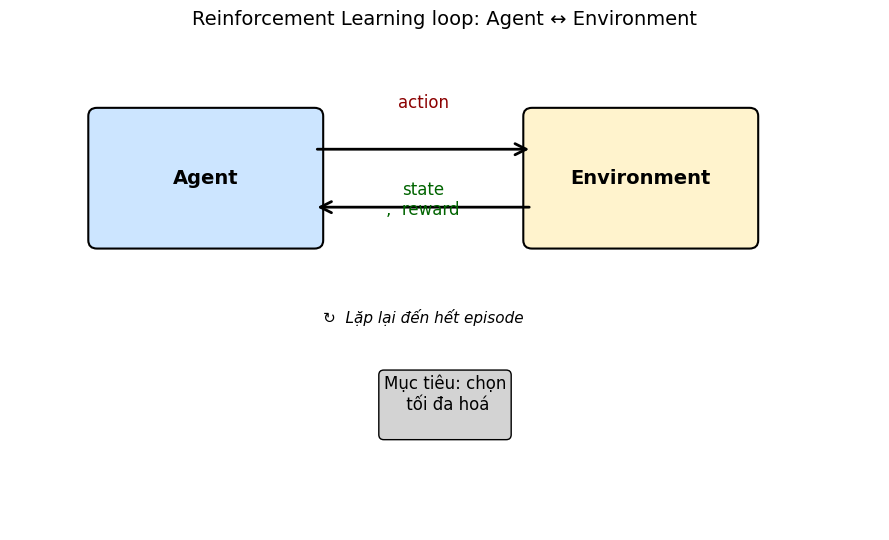

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')

# Agent box
agent = FancyBboxPatch((1, 3.5), 2.5, 1.5, boxstyle='round,pad=0.1',
                       facecolor='#cce5ff', edgecolor='black', linewidth=1.5)
ax.add_patch(agent)
ax.text(2.25, 4.25, 'Agent', ha='center', va='center', fontsize=14, fontweight='bold')

# Environment box
env = FancyBboxPatch((6, 3.5), 2.5, 1.5, boxstyle='round,pad=0.1',
                     facecolor='#fff3cd', edgecolor='black', linewidth=1.5)
ax.add_patch(env)
ax.text(7.25, 4.25, 'Environment', ha='center', va='center', fontsize=14, fontweight='bold')

# Action arrow (Agent -> Env)
ax.add_patch(FancyArrowPatch((3.5, 4.6), (6, 4.6), arrowstyle='->',
                             mutation_scale=20, color='black', linewidth=2))
ax.text(4.75, 4.85, 'action\n',
        ha='center', fontsize=12, color='darkred')

# State + Reward arrow (Env -> Agent)
ax.add_patch(FancyArrowPatch((6, 3.9), (3.5, 3.9), arrowstyle='->',
                             mutation_scale=20, color='black', linewidth=2))
ax.text(4.75, 3.55, 'state\n,  reward\n',
        ha='center', fontsize=12, color='darkgreen')

# Cycle indicator
ax.text(4.75, 2.5, '↻  Lặp lại đến hết episode', ha='center', fontsize=11, style='italic')

# Goal box at bottom
ax.text(5, 1.2, 'Mục tiêu: chọn\n tối đa hoá\n',
        ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgray'))

ax.set_title('Reinforcement Learning loop: Agent ↔ Environment', fontsize=14)
plt.tight_layout(); plt.show()

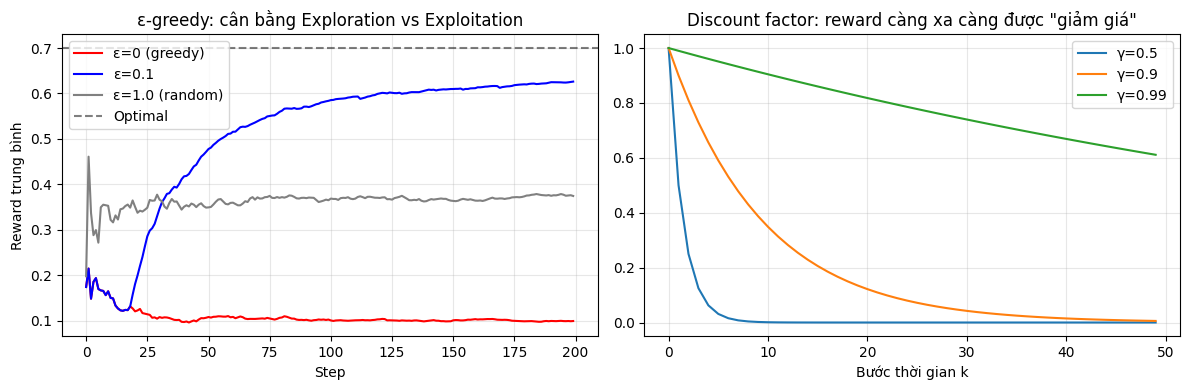

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Minh hoạ ε-greedy — vì sao cần exploration.
np.random.seed(0)
n_arms = 5
true_means = np.array([0.1, 0.3, 0.5, 0.7, 0.4])  # 5 cánh tay
n_steps = 200

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, eps, color in [('ε=0 (greedy)', 0.0, 'red'),
                          ('ε=0.1', 0.1, 'blue'),
                          ('ε=1.0 (random)', 1.0, 'gray')]:
    np.random.seed(0)
    Q = np.zeros(n_arms); n = np.zeros(n_arms); rewards = []
    for t in range(n_steps):
        if np.random.rand() < eps:
            a = np.random.randint(n_arms)
        else:
            a = int(np.argmax(Q))
        r = np.random.randn() * 0.1 + true_means[a]
        n[a] += 1
        Q[a] += (r - Q[a]) / n[a]
        rewards.append(r)
    cum = np.cumsum(rewards) / np.arange(1, n_steps + 1)
    axes[0].plot(cum, label=label, color=color)

axes[0].axhline(true_means.max(), color='black', linestyle='--', alpha=0.5, label='Optimal')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Reward trung bình')
axes[0].set_title('ε-greedy: cân bằng Exploration vs Exploitation')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Discount factor
gammas = [0.5, 0.9, 0.99]
ts = np.arange(50)
for g in gammas:
    axes[1].plot(ts, g**ts, label=f'γ={g}')
axes[1].set_xlabel('Bước thời gian k'); axes[1].set_ylabel('')
axes[1].set_title('Discount factor: reward càng xa càng được \"giảm giá\"')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

try:
    import gymnasium as gym
except ImportError:
    print('Chưa cài gymnasium — chạy: pip install gymnasium')
    raise

np.random.seed(42)
random.seed(42)

env = gym.make('FrozenLake-v1', is_slippery=False)
n_states  = env.observation_space.n      # 16
n_actions = env.action_space.n           # 4 (trái, dưới, phải, lên)
print(f'Số state: {n_states}, số action: {n_actions}')

# Bản đồ FrozenLake mặc định:
# S F F F
# F H F H
# F F F H
# H F F G
# S = start, F = frozen (đi được), H = hole, G = goal.

Số state: 16, số action: 4


In [13]:
Q = np.zeros((n_states, n_actions))

# Hyperparams
alpha    = 0.8       # learning rate
gamma    = 0.95      # discount factor
epsilon  = 1.0       # exploration rate (giảm dần)
eps_decay = 0.999   # Slower decay to allow more exploration
eps_min  = 0.01
n_episodes = 20000  # Increased number of episodes for more learning opportunities

rewards_history = []

for ep in range(n_episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    while not done:
        # ε-greedy: chọn ngẫu nhiên với xác suất ε.
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Cập nhật Q-table.
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

        state = next_state
        total_reward += reward

    epsilon = max(eps_min, epsilon * eps_decay)
    rewards_history.append(total_reward)

    if (ep + 1) % 2000 == 0: # Adjusted print frequency for more episodes
        avg = np.mean(rewards_history[-100:])
        print(f'Episode {ep+1:5d}  avg reward last 100: {avg:.2f}  ε = {epsilon:.3f}')

Episode  2000  avg reward last 100: 0.83  ε = 0.135
Episode  4000  avg reward last 100: 0.96  ε = 0.018
Episode  6000  avg reward last 100: 0.98  ε = 0.010
Episode  8000  avg reward last 100: 0.99  ε = 0.010
Episode 10000  avg reward last 100: 0.98  ε = 0.010
Episode 12000  avg reward last 100: 0.98  ε = 0.010
Episode 14000  avg reward last 100: 0.99  ε = 0.010
Episode 16000  avg reward last 100: 1.00  ε = 0.010
Episode 18000  avg reward last 100: 0.99  ε = 0.010
Episode 20000  avg reward last 100: 0.98  ε = 0.010


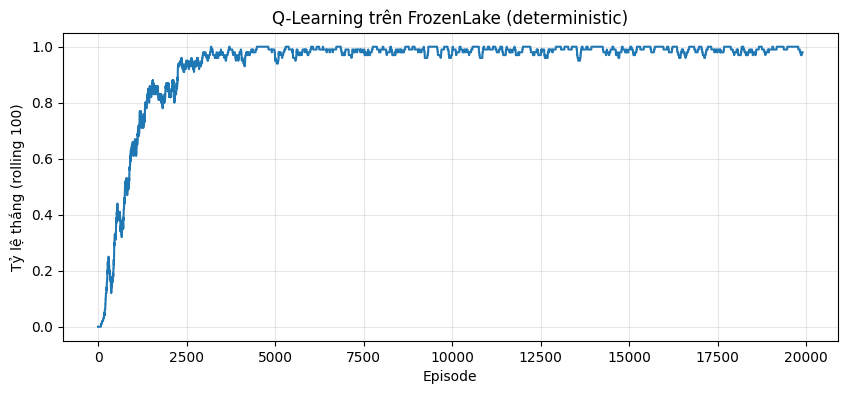

In [14]:
# Vẽ tỷ lệ thành công theo episode (rolling window 100).
rewards_arr = np.array(rewards_history)
rolling = np.convolve(rewards_arr, np.ones(100)/100, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rolling)
plt.xlabel('Episode'); plt.ylabel('Tỷ lệ thắng (rolling 100)')
plt.title('Q-Learning trên FrozenLake (deterministic)')
plt.grid(alpha=0.3); plt.show()

In [15]:
# Kiểm tra chính sách đã học bằng cách chạy 100 episode greedy.
wins = 0
for _ in range(100):
    state, _ = env.reset()
    done = False
    while not done:
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        if reward > 0: wins += 1
print(f'Tỷ lệ thắng greedy: {wins}/100')

# In bảng Q-table cho 4 ô đầu tiên
print('\nQ-table (4 hàng đầu — state 0,1,2,3):')
print('Action: [trái, dưới, phải, lên]')
for s in range(4):
    print(f'State {s}: {Q[s].round(3)}')


Tỷ lệ thắng greedy: 100/100

Q-table (4 hàng đầu — state 0,1,2,3):
Action: [trái, dưới, phải, lên]
State 0: [0.735 0.774 0.774 0.735]
State 1: [0.735 0.    0.815 0.774]
State 2: [0.774 0.857 0.774 0.815]
State 3: [0.815 0.    0.774 0.774]


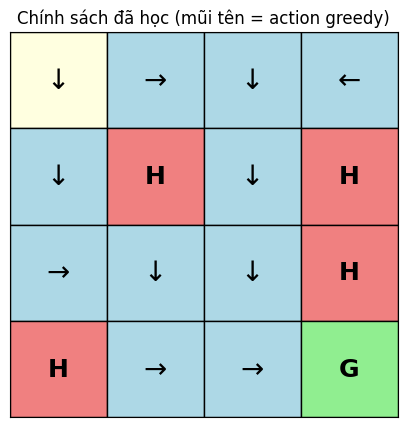

In [16]:
arrows = ['←', '↓', '→', '↑']
lake_map = ['S', 'F', 'F', 'F',
            'F', 'H', 'F', 'H',
            'F', 'F', 'F', 'H',
            'H', 'F', 'F', 'G']

fig, ax = plt.subplots(figsize=(5, 5))
for i in range(4):
    for j in range(4):
        s = i * 4 + j
        cell = lake_map[s]
        if cell in ('S', 'G'):
            color = 'lightgreen' if cell == 'G' else 'lightyellow'
        elif cell == 'H':
            color = 'lightcoral'
        else:
            color = 'lightblue'
        ax.add_patch(plt.Rectangle((j, 3-i), 1, 1, facecolor=color, edgecolor='black'))
        if cell == 'F' or cell == 'S':
            best_a = int(np.argmax(Q[s]))
            ax.text(j + 0.5, 3-i + 0.5, arrows[best_a], ha='center', va='center', fontsize=20)
        else:
            ax.text(j + 0.5, 3-i + 0.5, cell, ha='center', va='center', fontsize=18, fontweight='bold')
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Chính sách đã học (mũi tên = action greedy)')
plt.show()

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]   # 4
action_dim = env.action_space.n              # 2
print('state_dim:', state_dim, ' action_dim:', action_dim)

state_dim: 4  action_dim: 2


In [18]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )
    def forward(self, s):
        return self.net(s)

policy_net = QNetwork(state_dim, action_dim).to(device)
# Target network: bản sao tách riêng, cập nhật chậm để training ổn định.
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Replay buffer: lưu các transition (s, a, r, s', done) để sample mini-batch.
# Phá vỡ tương quan thời gian — quan trọng để training ổn định.
replay = deque(maxlen=10000)
batch_size = 64
gamma = 0.99
epsilon = 1.0
eps_decay = 0.995
eps_min = 0.05
target_update_freq = 10   # update target_net mỗi 10 episode

In [19]:
def select_action(state, eps):
    if random.random() < eps:
        return env.action_space.sample()
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        return int(policy_net(s).argmax(dim=1).item())

def train_step():
    if len(replay) < batch_size:
        return
    batch = random.sample(replay, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states      = torch.FloatTensor(np.array(states)).to(device)
    actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones       = torch.FloatTensor(dones).to(device)

    # Q-value hiện tại với action đã chọn.
    q_pred = policy_net(states).gather(1, actions).squeeze(1)
    # Target: r + γ max_a' Q_target(s', a'), với done=1 thì không cộng phần future.
    with torch.no_grad():
        q_next = target_net(next_states).max(1)[0]
        q_target = rewards + gamma * q_next * (1 - dones)

    loss = criterion(q_pred, q_target)
    optimizer.zero_grad(); loss.backward()
    # Clip gradient để tránh exploding.
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()
    return loss.item()

In [20]:
n_episodes = 300
ep_rewards = []

for ep in range(n_episodes):
    state, _ = env.reset(seed=ep)
    total = 0
    done = False
    while not done:
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay.append((state, action, reward, next_state, float(done)))
        train_step()
        state = next_state
        total += reward

    epsilon = max(eps_min, epsilon * eps_decay)
    ep_rewards.append(total)

    if ep % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (ep + 1) % 30 == 0:
        avg = np.mean(ep_rewards[-30:])
        print(f'Ep {ep+1:3d}  avg reward last 30: {avg:6.2f}  ε = {epsilon:.3f}')

Ep  30  avg reward last 30:  25.73  ε = 0.860
Ep  60  avg reward last 30:  28.43  ε = 0.740
Ep  90  avg reward last 30:  36.10  ε = 0.637
Ep 120  avg reward last 30:  57.13  ε = 0.548
Ep 150  avg reward last 30:  77.27  ε = 0.471
Ep 180  avg reward last 30:  50.97  ε = 0.406
Ep 210  avg reward last 30:  54.07  ε = 0.349
Ep 240  avg reward last 30:  73.00  ε = 0.300
Ep 270  avg reward last 30:  86.67  ε = 0.258
Ep 300  avg reward last 30:  92.47  ε = 0.222


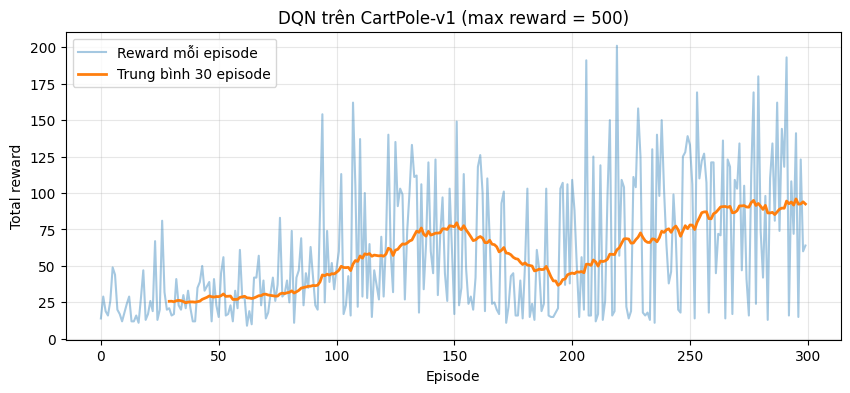

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(ep_rewards, alpha=0.4, label='Reward mỗi episode')
if len(ep_rewards) >= 30:
    rolling = np.convolve(ep_rewards, np.ones(30)/30, mode='valid')
    plt.plot(range(29, len(ep_rewards)), rolling, label='Trung bình 30 episode', linewidth=2)
plt.xlabel('Episode'); plt.ylabel('Total reward')
plt.title('DQN trên CartPole-v1 (max reward = 500)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Bài 1: FrozenLake với `is_slippery=True`

In [23]:
# Tải các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import random
import gymnasium as gym

# Thiết lập seed để đảm bảo khả năng tái lập
np.random.seed(42)
random.seed(42)

# Khởi tạo môi trường FrozenLake với is_slippery=True
env_slippery = gym.make('FrozenLake-v1', is_slippery=True)
n_states_slippery = env_slippery.observation_space.n
n_actions_slippery = env_slippery.action_space.n

print(f'Môi trường FrozenLake với is_slippery=True')
print(f'Số state: {n_states_slippery}, số action: {n_actions_slippery}')
print('\nBản đồ FrozenLake mặc định:')
# In bản đồ để dễ hình dung
for i in range(0, n_states_slippery, int(np.sqrt(n_states_slippery))):
    # Access the 'desc' attribute from the unwrapped environment
    row = [env_slippery.unwrapped.desc.flatten()[j].decode('utf-8') for j in range(i, i + int(np.sqrt(n_states_slippery)))]
    print(' '.join(row))

Môi trường FrozenLake với is_slippery=True
Số state: 16, số action: 4

Bản đồ FrozenLake mặc định:
S F F F
F H F H
F F F H
H F F G


In [24]:
Q_slippery = np.zeros((n_states_slippery, n_actions_slippery))

# Hyperparameters for Q-learning on slippery FrozenLake
alpha_slippery    = 0.8       # learning rate
gamma_slippery    = 0.95      # discount factor
epsilon_slippery  = 1.0       # exploration rate (giảm dần)
eps_decay_slippery = 0.999    # Slower decay for more exploration in a harder environment
eps_min_slippery  = 0.01
n_episodes_slippery = 5000    # As requested by the user

rewards_history_slippery = []

print(f'Bắt đầu huấn luyện Q-Learning trên FrozenLake (is_slippery=True) với {n_episodes_slippery} episodes...')

for ep in range(n_episodes_slippery):
    state, _ = env_slippery.reset()
    total_reward = 0
    done = False
    while not done:
        # ε-greedy: chọn ngẫu nhiên với xác suất ε.
        if random.random() < epsilon_slippery:
            action = env_slippery.action_space.sample()
        else:
            action = int(np.argmax(Q_slippery[state]))

        next_state, reward, terminated, truncated, _ = env_slippery.step(action)
        done = terminated or truncated

        # Cập nhật Q-table.
        # Only update if the next_state is not terminal (hole or goal) to prevent max(Q) on terminal states from influencing updates
        if not done:
            Q_slippery[state, action] += alpha_slippery * (reward + gamma_slippery * np.max(Q_slippery[next_state]) - Q_slippery[state, action])
        else:
            Q_slippery[state, action] += alpha_slippery * (reward - Q_slippery[state, action]) # No future reward if terminal

        state = next_state
        total_reward += reward

    epsilon_slippery = max(eps_min_slippery, epsilon_slippery * eps_decay_slippery)
    rewards_history_slippery.append(total_reward)

    if (ep + 1) % 500 == 0: # Print average reward every 500 episodes
        avg = np.mean(rewards_history_slippery[-100:])
        print(f'Episode {ep+1:4d}  avg reward last 100: {avg:.2f}  ε = {epsilon_slippery:.3f}')

Bắt đầu huấn luyện Q-Learning trên FrozenLake (is_slippery=True) với 5000 episodes...
Episode  500  avg reward last 100: 0.05  ε = 0.606
Episode 1000  avg reward last 100: 0.05  ε = 0.368
Episode 1500  avg reward last 100: 0.11  ε = 0.223
Episode 2000  avg reward last 100: 0.09  ε = 0.135
Episode 2500  avg reward last 100: 0.18  ε = 0.082
Episode 3000  avg reward last 100: 0.26  ε = 0.050
Episode 3500  avg reward last 100: 0.38  ε = 0.030
Episode 4000  avg reward last 100: 0.42  ε = 0.018
Episode 4500  avg reward last 100: 0.43  ε = 0.011
Episode 5000  avg reward last 100: 0.66  ε = 0.010


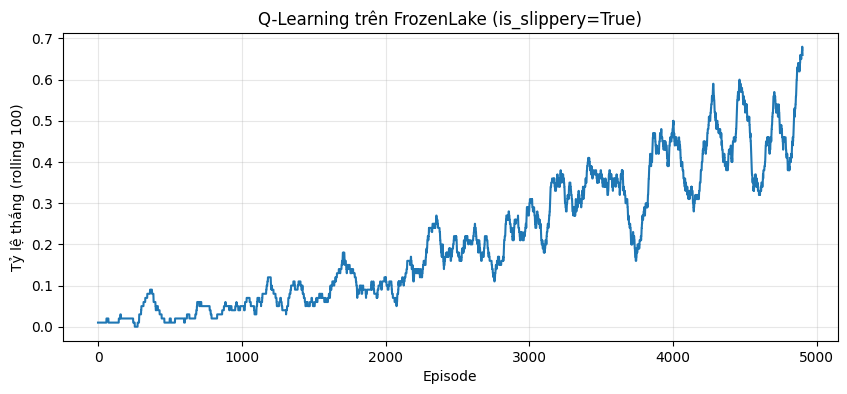

In [25]:
# Vẽ tỷ lệ thành công theo episode (rolling window 100) cho môi trường slippery.
rewards_arr_slippery = np.array(rewards_history_slippery)
# Calculate rolling average, ensure there are enough episodes for the window
if len(rewards_arr_slippery) >= 100:
    rolling_slippery = np.convolve(rewards_arr_slippery, np.ones(100)/100, mode='valid')
else:
    # If not enough episodes for a 100-episode window, just plot the raw rewards or an empty plot
    rolling_slippery = rewards_arr_slippery # Or handle as desired

plt.figure(figsize=(10, 4))
plt.plot(rolling_slippery)
plt.xlabel('Episode'); plt.ylabel('Tỷ lệ thắng (rolling 100)')
plt.title('Q-Learning trên FrozenLake (is_slippery=True)')
plt.grid(alpha=0.3); plt.show()

## Bài 2: Cải thiện DQN trên CartPole

In [27]:
# Re-defining train_step to include Double DQN
# tau for soft update
tau = 0.005

def train_step_ddqn_soft_update():
    if len(replay) < batch_size:
        return
    batch = random.sample(replay, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states      = torch.FloatTensor(np.array(states)).to(device)
    actions     = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones       = torch.FloatTensor(dones).to(device)

    # Q-value hiện tại với action đã chọn.
    q_pred = policy_net(states).gather(1, actions).squeeze(1)

    # Double DQN: chọn action từ policy_net, đánh giá bằng target_net
    with torch.no_grad():
        next_actions = policy_net(next_states).argmax(1, keepdim=True) # Select action with policy_net
        q_next = target_net(next_states).gather(1, next_actions).squeeze(1) # Evaluate with target_net
        q_target = rewards + gamma * q_next * (1 - dones)

    loss = criterion(q_pred, q_target)
    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()

    # Soft update the target network
    for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
        target_param.data.copy_(tau * policy_param.data + (1 - tau) * target_param.data)

    return loss.item()

In [28]:
# Reset the environment, networks, optimizer, and replay buffer for a fresh start
env = gym.make('CartPole-v1') # Re-create environment to reset state
policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()
optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
replay = deque(maxlen=10000) # Clear replay buffer

# Reset hyperparameters for this run
n_episodes_ddqn = 1000
ep_rewards_ddqn = []
epsilon_ddqn = 1.0       # exploration rate (giảm dần)
eps_decay_ddqn = 0.995
eps_min_ddqn = 0.05

print(f"Bắt đầu huấn luyện Double DQN với Soft Update trên CartPole-v1 với {n_episodes_ddqn} episodes...")

for ep in range(n_episodes_ddqn):
    state, _ = env.reset(seed=ep)
    total = 0
    done = False
    while not done:
        action = select_action(state, epsilon_ddqn)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        replay.append((state, action, reward, next_state, float(done)))
        train_step_ddqn_soft_update() # Use the new training step function
        state = next_state
        total += reward

    epsilon_ddqn = max(eps_min_ddqn, epsilon_ddqn * eps_decay_ddqn)
    ep_rewards_ddqn.append(total)

    # The target network is soft-updated within train_step_ddqn_soft_update, so no hard copy here

    if (ep + 1) % 100 == 0: # Print every 100 episodes for 1000 total
        avg = np.mean(ep_rewards_ddqn[-100:])
        print(f'Ep {ep+1:4d}  avg reward last 100: {avg:6.2f}  ε = {epsilon_ddqn:.3f}')

Bắt đầu huấn luyện Double DQN với Soft Update trên CartPole-v1 với 1000 episodes...
Ep  100  avg reward last 100:  36.47  ε = 0.606
Ep  200  avg reward last 100:  74.22  ε = 0.367
Ep  300  avg reward last 100:  86.99  ε = 0.222
Ep  400  avg reward last 100: 168.25  ε = 0.135
Ep  500  avg reward last 100: 179.08  ε = 0.082
Ep  600  avg reward last 100: 210.80  ε = 0.050
Ep  700  avg reward last 100: 140.55  ε = 0.050
Ep  800  avg reward last 100: 209.08  ε = 0.050
Ep  900  avg reward last 100: 177.00  ε = 0.050
Ep 1000  avg reward last 100: 205.77  ε = 0.050


### Visualization of Double DQN with Soft Updates

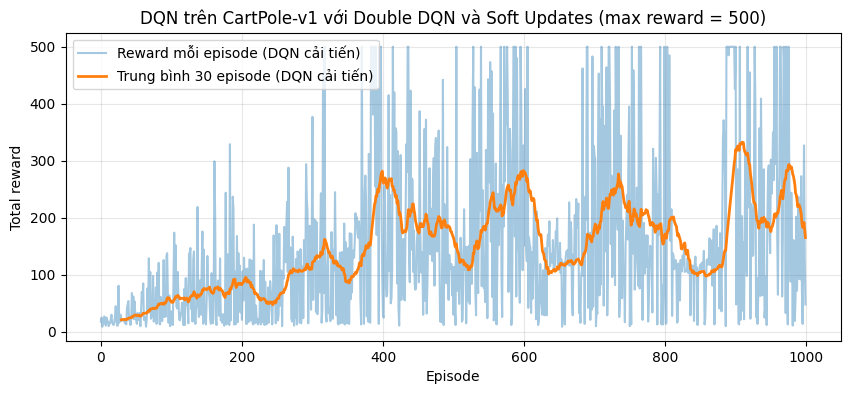

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(ep_rewards_ddqn, alpha=0.4, label='Reward mỗi episode (DQN cải tiến)')
if len(ep_rewards_ddqn) >= 30:
    rolling_ddqn = np.convolve(ep_rewards_ddqn, np.ones(30)/30, mode='valid')
    plt.plot(range(29, len(ep_rewards_ddqn)), rolling_ddqn, label='Trung bình 30 episode (DQN cải tiến)', linewidth=2)
plt.xlabel('Episode'); plt.ylabel('Total reward')
plt.title('DQN trên CartPole-v1 với Double DQN và Soft Updates (max reward = 500)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### So sánh và Báo cáo

Sau khi chạy xong đoạn code trên, hãy quan sát biểu đồ và so sánh với biểu đồ của phiên bản DQN ban đầu. Hãy xem xét các yếu tố sau:

*   **Tốc độ hội tụ:** Phiên bản cải tiến có đạt được điểm thưởng tối đa (500) nhanh hơn và ổn định hơn không?
*   **Độ ổn định:** Đường cong rolling average có mượt hơn hay ít biến động hơn không?

Dựa trên kết quả thực nghiệm, bạn có thể báo cáo liệu Double DQN và Soft Update có giúp cải thiện quá trình huấn luyện DQN trên CartPole hay không.

## Bài 3: Render và quay video (nâng cao)

In [30]:
!pip install moviepy

In [31]:
from gymnasium.wrappers import RecordVideo

env_render = gym.make('CartPole-v1', render_mode='rgb_array')
env_render = RecordVideo(env_render, video_folder='./videos', episode_trigger=lambda x: True)

state, _ = env_render.reset()
done = False
while not done:
    action = select_action(state, eps=0)   # greedy
    state, _, term, trunc, _ = env_render.step(action)
    done = term or trunc
env_render.close()

print("Video đã được lưu vào thư mục './videos'")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Video đã được lưu vào thư mục './videos'
